Saving Iris.csv to Iris.csv

K = 2
Manual Silhouette Score : 0.6254
Manual DB Index         : 0.5021
Manual WCSS             : 70649.3547

K = 3
Manual Silhouette Score : 0.5899
Manual DB Index         : 0.5018
Manual WCSS             : 31370.0160

K = 4
Manual Silhouette Score : 0.5681
Manual DB Index         : 0.5081
Manual WCSS             : 17872.3597


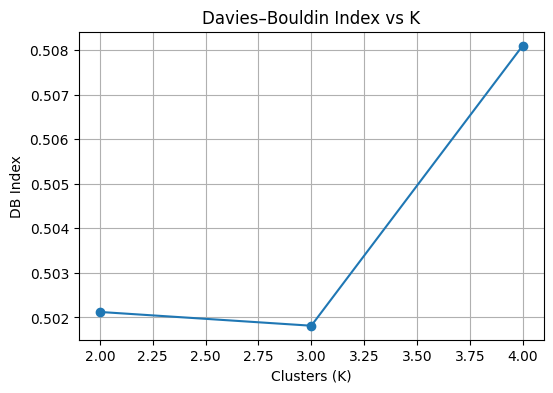

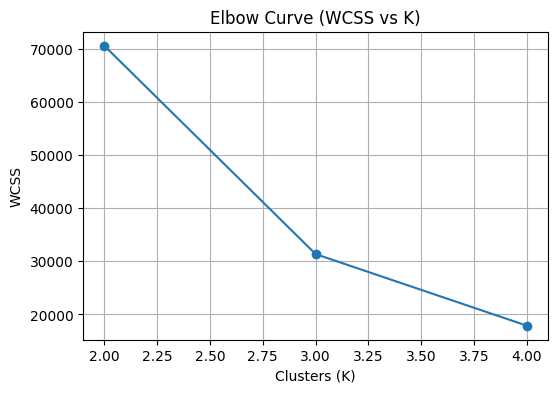

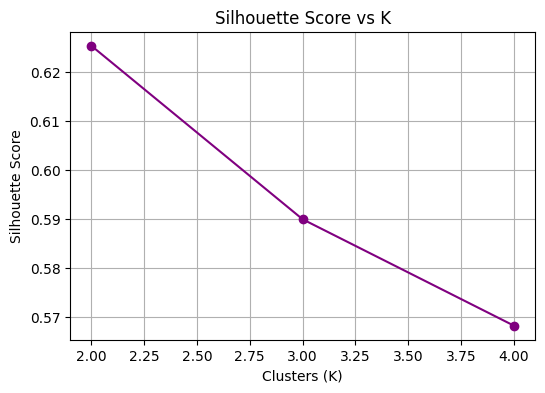

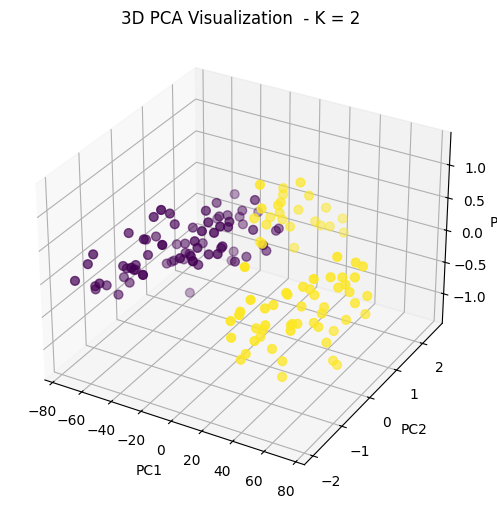

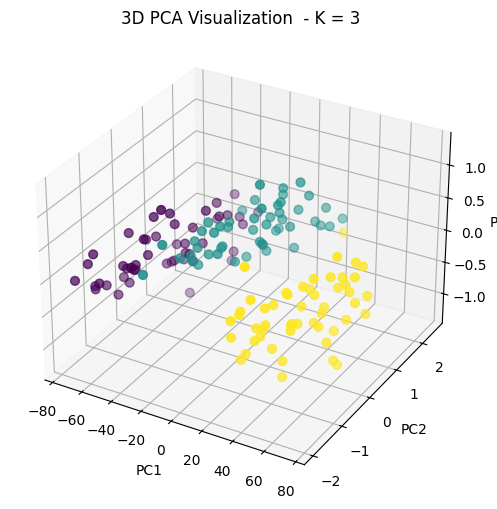

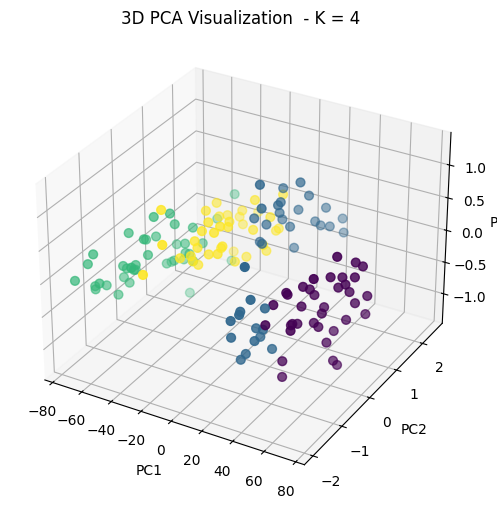

In [ ]:
import numpy as np
import pandas as pd
import random
import math
import matplotlib.pyplot as plt
from google.colab import files

uploaded = files.upload()
file_name = list(uploaded.keys())[0]

if file_name.endswith(".csv"):
    df = pd.read_csv(file_name)
else:
    df = pd.read_excel(file_name)

X = df.select_dtypes(include=[np.number]).values


def manual_kmeans(X, k, max_iter=100):
    idx = random.sample(range(len(X)), k)
    centroids = X[idx]

    for _ in range(max_iter):
        labels = []
        for x in X:
            dists = [np.linalg.norm(x - c) for c in centroids]
            labels.append(np.argmin(dists))
        labels = np.array(labels)

        new_centroids = []
        for c in range(k):
            pts = X[labels == c]
            if len(pts) > 0:
                new_centroids.append(pts.mean(axis=0))
            else:
                new_centroids.append(centroids[c])

        new_centroids = np.array(new_centroids)

        if np.allclose(new_centroids, centroids):
            break
        centroids = new_centroids

    return labels, centroids



def manual_silhouette(X, labels):
    sil = []
    for i in range(len(X)):
        same = X[labels == labels[i]]
        other = [X[labels == c] for c in set(labels) if c != labels[i]]

        a = np.mean([np.linalg.norm(X[i] - p) for p in same])
        b = min(np.mean([np.linalg.norm(X[i] - p) for p in cl]) for cl in other)

        sil.append((b - a) / max(a, b))
    return np.mean(sil)

def manual_davies_bouldin(X, labels, centroids):
    k = len(centroids)
    S = []
    for c in range(k):
        pts = X[labels == c]
        if len(pts) == 0:
            S.append(0)
        else:
            S.append(np.mean([np.linalg.norm(p - centroids[c]) for p in pts]))

    db_scores = []
    for i in range(k):
        max_ratio = -999
        for j in range(k):
            if i != j:
                M = np.linalg.norm(centroids[i] - centroids[j])
                val = (S[i] + S[j]) / M
                max_ratio = max(max_ratio, val)
        db_scores.append(max_ratio)

    return np.mean(db_scores)

def compute_wcss(X, labels, centroids):
    total = 0
    for i, x in enumerate(X):
        c = labels[i]
        total += np.linalg.norm(x - centroids[c])**2
    return total

def manual_pca(X):
    X_mean = X - np.mean(X, axis=0)

    cov = np.zeros((X.shape[1], X.shape[1]))
    for i in range(X.shape[1]):
        for j in range(X.shape[1]):
            cov[i][j] = np.mean(X_mean[:, i] * X_mean[:, j])

    def power_iter(A, steps=1000):
        v = np.random.rand(A.shape[0])
        for _ in range(steps):
            v = A.dot(v)
            v = v / np.linalg.norm(v)
        return v

    pc1 = power_iter(cov)
    cov2 = cov - np.outer(pc1, pc1) * np.dot(pc1, pc1)
    pc2 = power_iter(cov2)

    proj = np.column_stack([X_mean.dot(pc1), X_mean.dot(pc2)])
    return proj

# ---------------------------------------------------------
# RUN FOR K = 2, 3, 4
# ---------------------------------------------------------
Ks = [2, 3, 4]
db_list = []
sil_list = []
wcss_list = []

for k in Ks:
    labels, centroids = manual_kmeans(X, k)

    sil = manual_silhouette(X, labels)
    db = manual_davies_bouldin(X, labels, centroids)
    wcss = compute_wcss(X, labels, centroids)

    sil_list.append(sil)
    db_list.append(db)
    wcss_list.append(wcss)

    print(f"\nK = {k}")
    print(f"Manual Silhouette Score : {sil:.4f}")
    print(f"Manual DB Index         : {db:.4f}")
    print(f"Manual WCSS             : {wcss:.4f}")

plt.figure(figsize=(6,4))
plt.plot(Ks, db_list, marker='o')
plt.title("Davies–Bouldin Index vs K")
plt.xlabel("Clusters (K)")
plt.ylabel("DB Index")
plt.grid(True)
plt.show()


plt.figure(figsize=(6,4))
plt.plot(Ks, wcss_list, marker='o')
plt.title("Elbow Curve (WCSS vs K)")
plt.xlabel("Clusters (K)")
plt.ylabel("WCSS")
plt.grid(True)
plt.show()


plt.figure(figsize=(6,4))
plt.plot(Ks, sil_list, marker='o', color='purple')
plt.title("Silhouette Score vs K")
plt.xlabel("Clusters (K)")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()



from mpl_toolkits.mplot3d import Axes3D

def manual_pca(X, components=3):
    # Step 1: Standardize
    X_mean = X - np.mean(X, axis=0)

    # Step 2: Covariance
    cov_mat = np.cov(X_mean, rowvar=False)

    # Step 3: Eigen decomposition
    eigen_vals, eigen_vecs = np.linalg.eig(cov_mat)

    # Step 4: Sort by eigenvalues
    idx = np.argsort(eigen_vals)[::-1]
    eigen_vecs = eigen_vecs[:, idx]

    # Step 5: Select top components
    W = eigen_vecs[:, :components]

    # Step 6: Transform
    X_reduced = X_mean.dot(W)

    return X_reduced


for i, k in enumerate(Ks):
    labels, centroids = manual_kmeans(X, k)

    # PCA transform to 3D
    X_pca3 = manual_pca(X, components=3)

    fig = plt.figure(figsize=(8,6))
    ax = fig.add_subplot(111, projection='3d')

    scatter = ax.scatter(
        X_pca3[:, 0], X_pca3[:, 1], X_pca3[:, 2],
        c=labels, s=40
    )

    ax.set_title(f"3D PCA Visualization  - K = {k}")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_zlabel("PC3")

    plt.show()

In [ ]:
# Run K-means only for the correct cluster count
k = 3
labels, centroids = manual_kmeans(X, k)

import plotly.graph_objects as go
import numpy as np

x1 = X[:, 0]
x2 = X[:, 1]

colors = ['black','blue','green','pink']

fig = go.Figure()

for c in range(k):
    fig.add_trace(go.Scatter(
        x=x1[labels == c],
        y=x2[labels == c],
        mode='markers',
        name=f"Cluster {c}",
        marker=dict(size=8, color=colors[c])
    ))

fig.add_trace(go.Scatter(
    x=centroids[:, 0],
    y=centroids[:, 1],
    mode='markers',
    name='Centroids',
    marker=dict(size=18, symbol='x', color='yellow', line=dict(width=3,color='black'))
))

fig.update_layout(
    title="K-Means Clustering (K=3) on Iris Dataset",
    xaxis_title="Feature 1",
    yaxis_title="Feature 2",
    template="simple_white"
)

fig.show()
